# CAPM & Beta Calculator

Calculates a stock's beta against a market index, its CAPM-implied expected return, and Jensen's alpha (actual return vs. CAPM-expected return) using live daily price data pulled via `yfinance`. Built as a standalone tool so the same beta/CAPM logic can feed the discount rate in a DCF valuation, or be run against any stock/index pair.

**Note:** all price data is pulled live at run time, so re-running this notebook on a different day will produce different numbers. The results below reflect one specific run (see README for the date).

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

## 1. Pull price history and align trading calendars

Fetch 5 years of daily closing prices for the target stock and its benchmark index, and compute each one's daily % return. Since a stock and an index don't always share identical trading calendars, the two return series are explicitly intersected on date before being combined — this also drops the leading `NaN` each series gets from `pct_change()`'s first row.

In [2]:
#Sorting data and collecting history

#Gets the ticker from the User provided its from LSE
Stockticker = "RR.L"
stock = yf.download(Stockticker, period= "5y")
market = yf.download("^FTSE", period = "5y")

#Creates column for both the stock and the market daily returns
stock_returns = stock["Close"].pct_change()
market_returns = market["Close"].pct_change()

#Align on dates both series actually share, then drop the leading NaN from pct_change
common_dates = stock_returns.dropna().index.intersection(market_returns.dropna().index)

D = pd.DataFrame()
D["Stock_d_return"] = stock_returns.loc[common_dates]
D["Market_d_return"] = market_returns.loc[common_dates]

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


## 2. Beta and CAPM expected return

Beta is the covariance of the stock's returns with the market's returns, divided by the market's variance — it measures how much the stock moves relative to a 1:1 move in the market (beta > 1 = more volatile than the market, beta < 1 = less).

CAPM expected return = risk-free rate + beta × (market return − risk-free rate). The risk-free rate here is a UK gilt yield, manually entered from [Trading Economics](https://tradingeconomics.com/united-kingdom/government-bond-yield) rather than pulled live — update it before re-running for a current result.

In [3]:
#Calculations to find a value for CAPM 

#To calculate beta,
#beta = cov(Market, stock)/ var(Market)
beta = D["Stock_d_return"].cov(D["Market_d_return"]) / D["Market_d_return"].var()
#if beta = 1 means that the stock moves in a 1 to 1 fashion with the market.
#if beta #0.5 , means the stock moves 0.5 for every 1 that beta moves

#To calculate CAPM
#Capm = Risk free rate ( Rfr) + beta(Annual Market return - Rfr)
#To get risk free rate we will use a UK Gilt so Gilt = Rfr
#https://tradingeconomics.com/united-kingdom/government-bond-yield
Rfr= 0.051626
market_cumulative_return = (1 + D["Market_d_return"]).prod()
n = len(D)
market_annual_return = (market_cumulative_return **(252/n))-1
CAPM =  Rfr + beta*(market_annual_return - Rfr)


## 3. Jensen's alpha

Alpha is the stock's actual annualized return minus its CAPM-expected return — the return earned above (or below) what its risk level alone would predict.

In [4]:
#To calculate  (Jensen's alpha)
stock_cumulative_return = (1 + D["Stock_d_return"]).prod()
stock_cumprod = (1 + D["Stock_d_return"]).cumprod()
market_cumulative_return = (1 + D["Market_d_return"]).prod()
FTSE_cumprod = (1 + D["Market_d_return"]).cumprod()
stock_annual_return = ( stock_cumulative_return) ** (252/n) - 1

alpha = stock_annual_return - CAPM

np.float64(0.5679202877485404)

## 4. Summary stats

**Sanity check:** RR's ~57% alpha over this window is a reflection of Rolls-Royce's exceptional post-COVID share price recovery, not a calculation error — a genuinely unusual result for this specific stock and time period, not a typical alpha figure.

In [5]:
#Checkpoint with all relevant stats
print(f"Stock Annual Return: {stock_annual_return:.2%}")
print(f"Risk Free Rate: {Rfr:.2%}")
print(f"Market Return: {market_annual_return:.2%}")
print(f"Beta: {beta:.2f}")
print(f"CAPM Expected Return: {CAPM:.2%}")
print(f"Alpha: {alpha:.2%}")

Stock Annual Return: 67.68%
Risk Free Rate: 5.16%
Market Return: 8.68%
Beta: 1.63
CAPM Expected Return: 10.88%
Alpha: 56.79%


## 5. Stock vs. benchmark: growth of £1

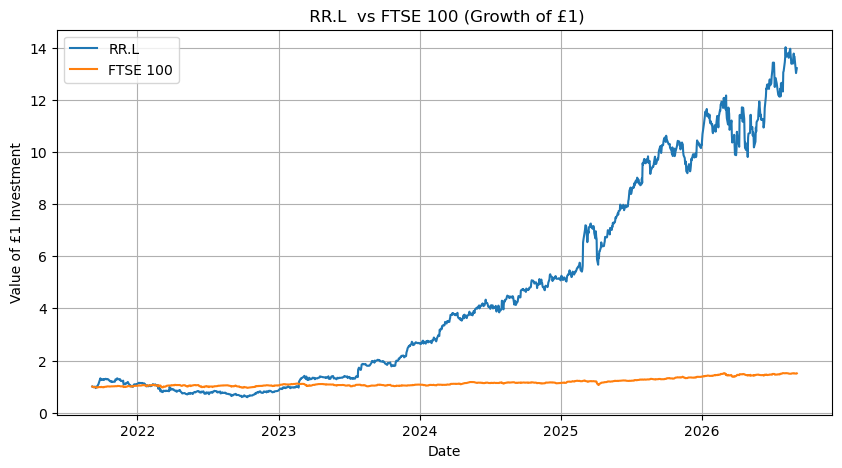

In [6]:
stock_index = stock_cumprod/ stock_cumprod.iloc[0]
FTSE_index = FTSE_cumprod/ FTSE_cumprod.iloc[0]

plt.figure(figsize=(10,5))

plt.plot(stock_index, label=Stockticker)
plt.plot(FTSE_index, label="FTSE 100")

plt.title(f" {Stockticker}  vs FTSE 100 (Growth of £1)")
plt.ylabel("Value of £1 Investment")
plt.xlabel("Date")

plt.legend()
plt.grid(True)

plt.show()